# Insurance Cost Prediction

## 🎯 Goal
To predict medical insurance charges based on features such as age, BMI, number of children, smoking status, and region.

## Problem Type
This is a **Regression problem** because the target variable (`charges`) is a continuous numeric value.

## 📦 Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

## Loading and Exploring Data

In [2]:
insurance_data = pd.read_csv(r"C:\Projects\Machine Learning\Insurance Cost Prediction\insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance_data.shape

(1338, 7)

In [4]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Data Conversion

In [6]:
for i in insurance_data.index:
    if(insurance_data.loc[i, 'sex'] == 'female'):
        insurance_data.loc[i, 'sex'] = 1
    else:
        insurance_data.loc[i, 'sex'] = 0
    if(insurance_data.loc[i, 'smoker'] == 'yes'):
        insurance_data.loc[i, 'smoker'] = 1
    else:
        insurance_data.loc[i, 'smoker'] = 0

In [7]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


## Visualization

Text(0, 0.5, 'Count')

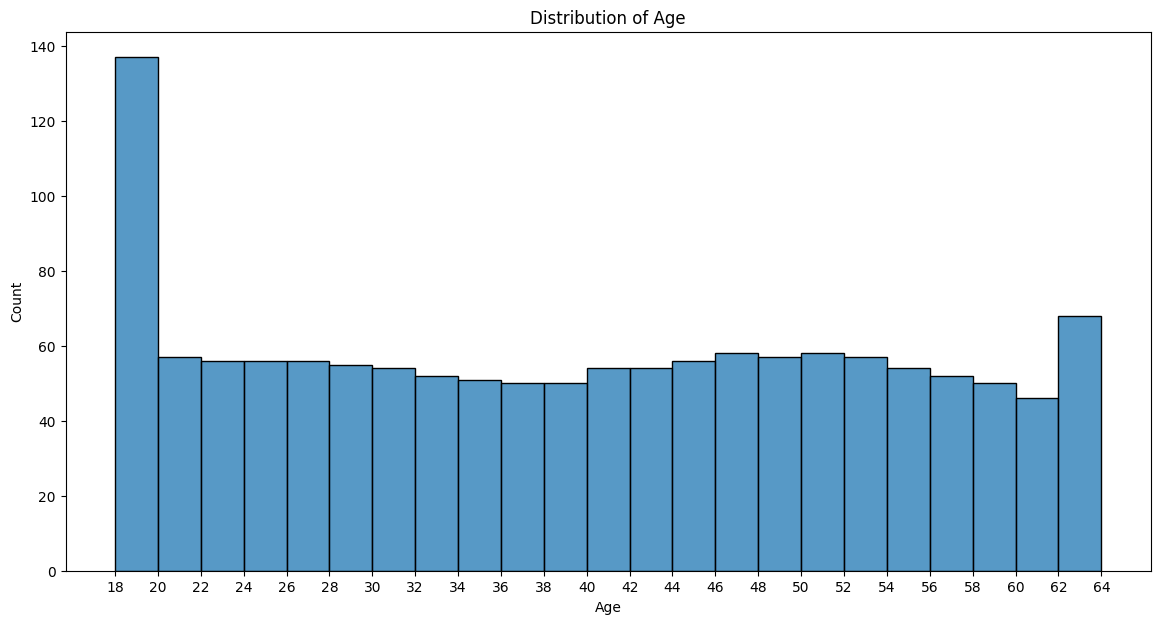

In [8]:
plt.figure(figsize=(14,7))

sns.histplot(insurance_data['age'], bins=23)
plt.xticks(np.arange(18, 65, 2))

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")

- This plot suggest that people from age 18-20 years took insurance than other age groups.
- Also age groups except 18-20 years have similar count of people who took insurance.

In [9]:
avg_region_charges = insurance_data.groupby('region').charges.mean()
avg_region_charges

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

([<matplotlib.axis.YTick at 0x1b7f1372210>,
 [Text(0, 0, '0'),
  Text(0, 2000, '2000'),
  Text(0, 4000, '4000'),
  Text(0, 6000, '6000'),
  Text(0, 8000, '8000'),
  Text(0, 10000, '10000'),
  Text(0, 12000, '12000'),
  Text(0, 14000, '14000'),
  Text(0, 16000, '16000')])

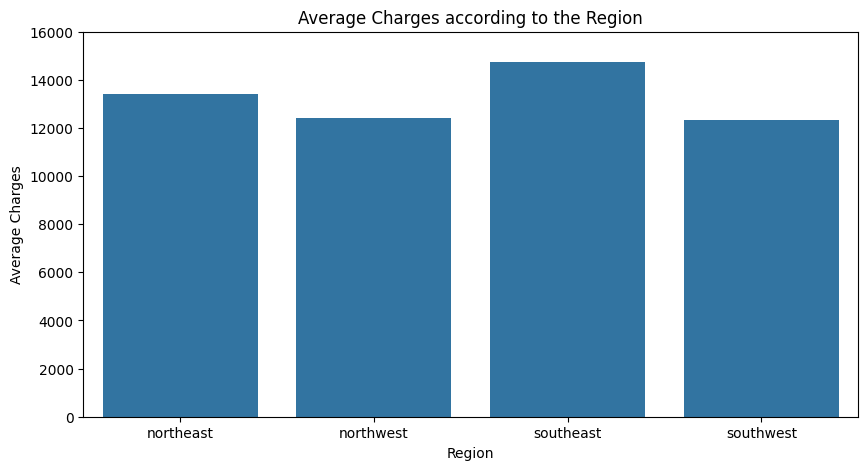

In [10]:
plt.figure(figsize=(10,5))\

sns.barplot(x= avg_region_charges.index, y=avg_region_charges)
plt.title("Average Charges according to the Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.yticks(np.arange(0, 16001, 2000))

- According to this plot all four region doesn't have big difference in average charges which is between 12000 to 16000.

([<matplotlib.axis.YTick at 0x1b7f13cfb10>,
 [Text(0, 0, '0'),
  Text(0, 5000, '5000'),
  Text(0, 10000, '10000'),
  Text(0, 15000, '15000'),
  Text(0, 20000, '20000'),
  Text(0, 25000, '25000'),
  Text(0, 30000, '30000'),
  Text(0, 35000, '35000'),
  Text(0, 40000, '40000'),
  Text(0, 45000, '45000'),
  Text(0, 50000, '50000'),
  Text(0, 55000, '55000'),
  Text(0, 60000, '60000'),
  Text(0, 65000, '65000')])

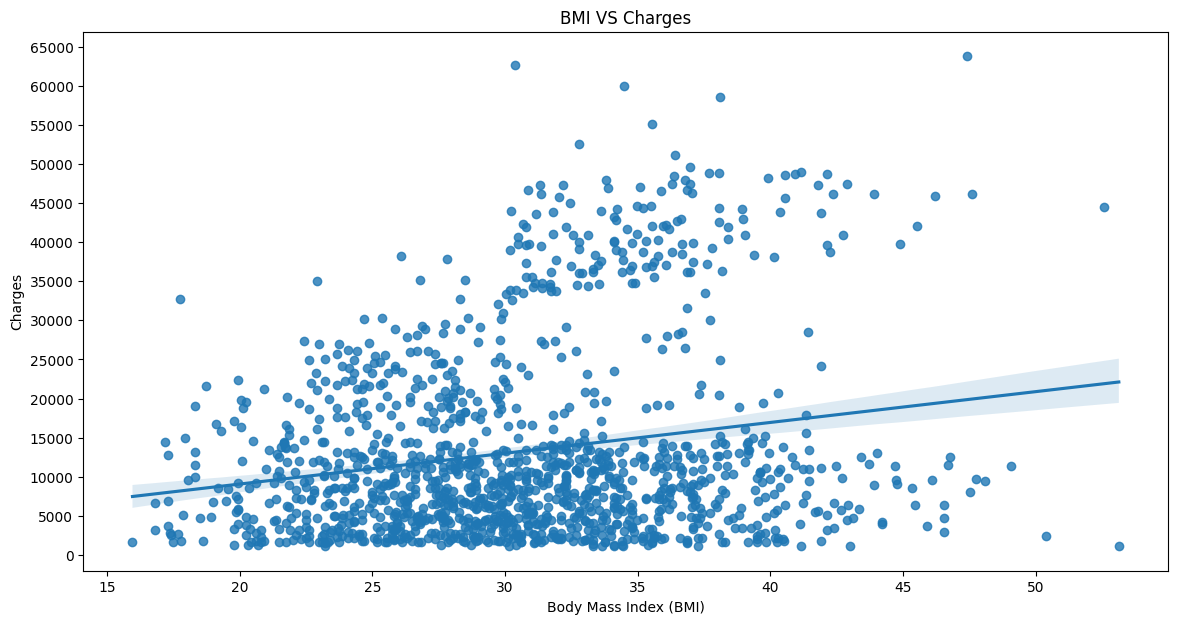

In [11]:
plt.figure(figsize=(14, 7))

sns.regplot(x=insurance_data.bmi, y=insurance_data.charges)
plt.title("BMI VS Charges")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Charges")
plt.yticks(np.arange(0, 65001, 5000))

- The scatter plot shows a positive relationship between BMI and insurance charges.
- However, the data points are widely scattered, indicating that BMI alone is not a strong predictor of insurance cost.

([<matplotlib.axis.YTick at 0x1b7f1481f90>,
 [Text(0, 0, '0'),
  Text(0, 5000, '5000'),
  Text(0, 10000, '10000'),
  Text(0, 15000, '15000'),
  Text(0, 20000, '20000'),
  Text(0, 25000, '25000'),
  Text(0, 30000, '30000'),
  Text(0, 35000, '35000'),
  Text(0, 40000, '40000'),
  Text(0, 45000, '45000'),
  Text(0, 50000, '50000'),
  Text(0, 55000, '55000'),
  Text(0, 60000, '60000'),
  Text(0, 65000, '65000')])

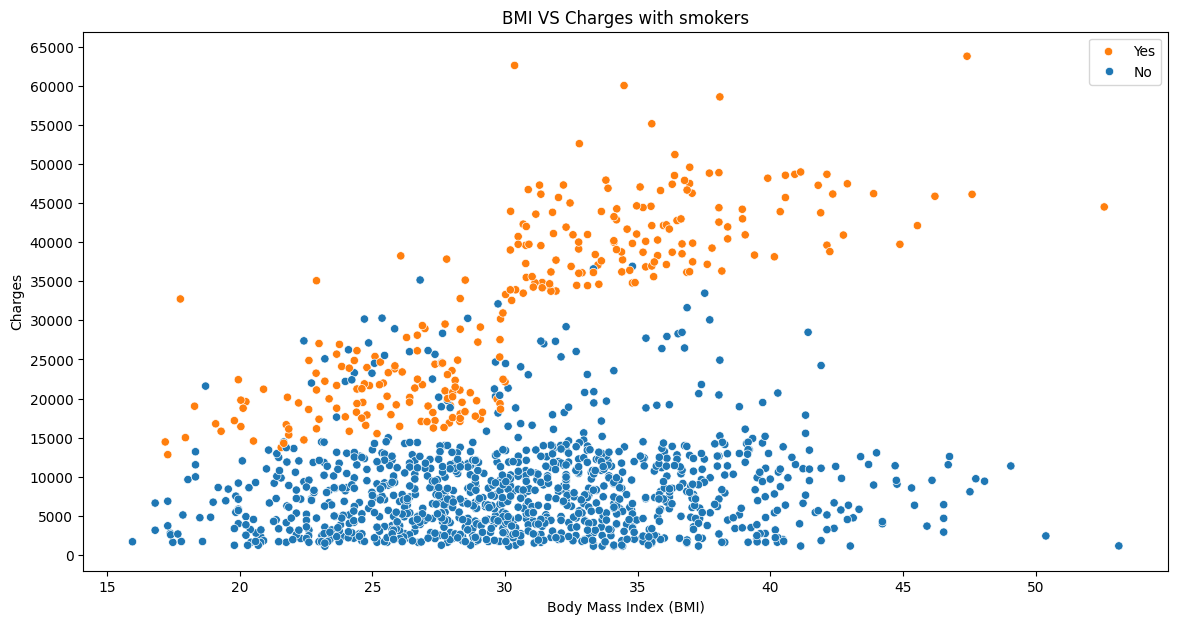

In [12]:
plt.figure(figsize=(14,7))

sns.scatterplot(x=insurance_data.bmi, y=insurance_data.charges, hue=insurance_data.smoker)
plt.legend(['Yes', 'No'])
plt.title("BMI VS Charges with smokers")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Charges")
plt.yticks(np.arange(0, 65001, 5000))

- It shows the people who smoke have to pay more charges for insurance than non-smokers.

([<matplotlib.axis.XTick at 0x1b7f153cb90>,
 [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

c:\Users\kriis\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


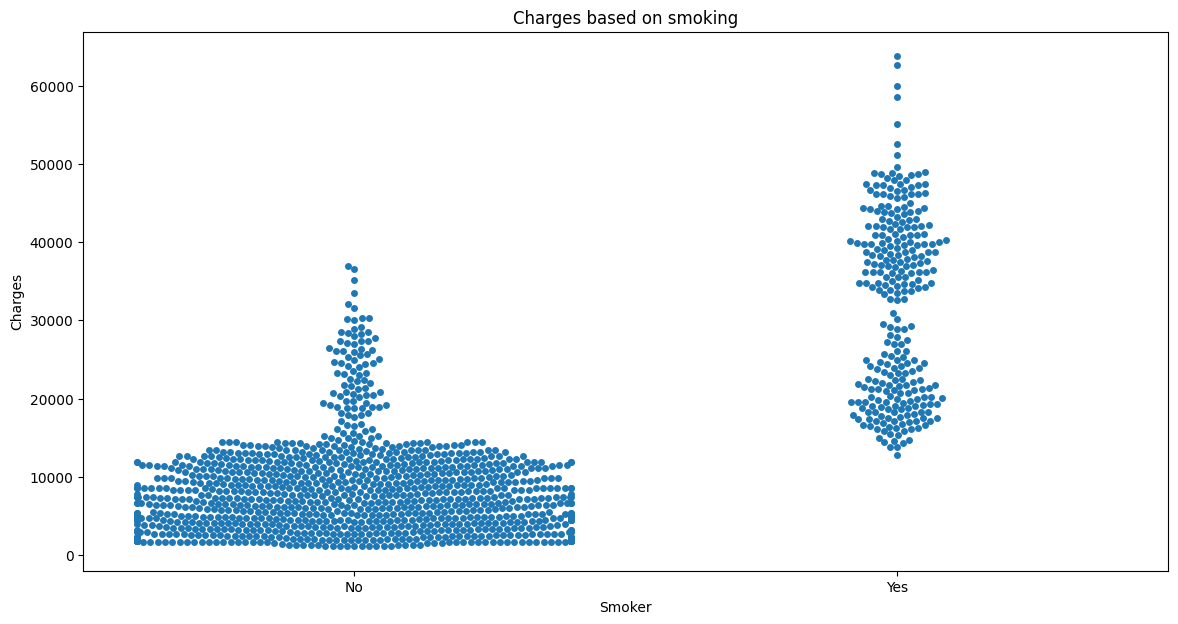

In [13]:
plt.figure(figsize=(14,7))

sns.swarmplot(x=insurance_data['smoker'], y=insurance_data['charges'])
plt.title('Charges based on smoking')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.xticks([0,1], ['No','Yes'])
# plt.xticks(locations, labels) when we pass only one argument it consider it as labels also.

- The plot clearly shows that non-smokers pay significantly lower insurance charges compared to smokers.
- Smoking status appears to be the strongest factor influencing medical insurance cost in this dataset.

([<matplotlib.axis.YTick at 0x1b7f1aa0b90>,
 [Text(0, 0, '0'),
  Text(0, 2500, '2500'),
  Text(0, 5000, '5000'),
  Text(0, 7500, '7500'),
  Text(0, 10000, '10000'),
  Text(0, 12500, '12500'),
  Text(0, 15000, '15000'),
  Text(0, 17500, '17500'),
  Text(0, 20000, '20000'),
  Text(0, 22500, '22500'),
  Text(0, 25000, '25000'),
  Text(0, 27500, '27500'),
  Text(0, 30000, '30000')])

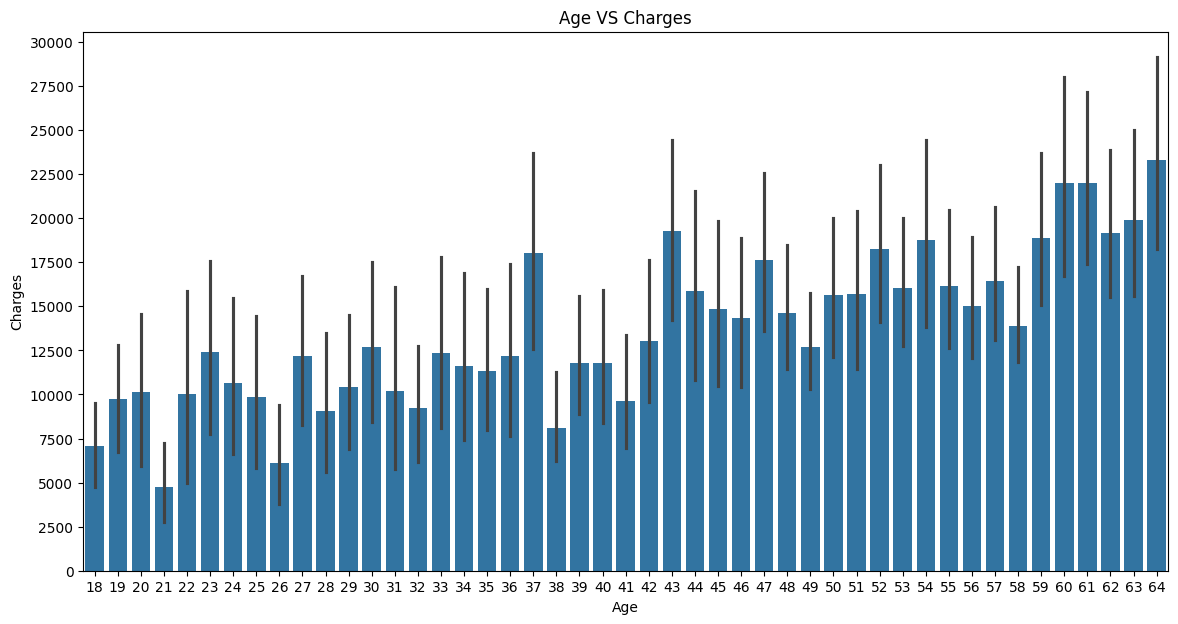

In [14]:
plt.figure(figsize=(14,7))

sns.barplot(x=insurance_data['age'], y=insurance_data['charges'])
plt.title("Age VS Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.yticks(np.arange(0, 30001, 2500))

- The plot shows that average insurance charges increase with age.
- However, the variability in charges also increases at higher ages, indicating that age alone does not fully explain insurance cost.
- Other factors such as smoking status likely play a significant role.

## Selecting and Splitting Features

In [15]:
y = insurance_data.charges
X = insurance_data[['age', 'sex', 'bmi', 'children', 'smoker']]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

## Decision Tree

### best max_leaf_nodes value

In [19]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=1)
    model.fit(train_X, train_y)

    predicted_charges = model.predict(val_X)
    mae = mean_absolute_error(val_y, predicted_charges)
    return mae

best_mae = float('inf') # very big positive value
for max_leaf_nodes in [5, 25, 50, 100, 250, 500]:
    mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
    if(mae < best_mae):
        best_mae = int(mae)
        best_leaf_nodes = max_leaf_nodes
print(f"Lowest mae: {best_mae} \t\t with max leaf nodes: {best_leaf_nodes}")

Lowest mae: 2477 		 with max leaf nodes: 25


### Final Optimized Decision Tree

In [24]:
insurance_model = DecisionTreeRegressor(max_leaf_nodes=best_leaf_nodes, random_state=1)
insurance_model.fit(train_X, train_y)

predicted_charges = insurance_model.predict(val_X)
print(int(mean_absolute_error(val_y, predicted_charges)))
print(predicted_charges[0:5])

2477
[ 3360.75017725 12567.1237413  10578.58094517 10578.58094517
  3360.75017725]


## Random Forests

In [23]:
model = RandomForestRegressor(random_state=1)
model.fit(train_X, train_y)

predicted_charges = model.predict(val_X)
print(f"MAE: {int(mean_absolute_error(val_y, predicted_charges))}")
print(f"Predicted Charges by Random Forests: {predicted_charges[0:5]}")

MAE: 2760
Predicted Charges by Random Forests: [ 1342.686288  12838.0555872  8978.282505  12547.528458   2539.5038368]


## Conclusion
- Decision Tree after tuning gave the best result in this experiment.
### Comparison:
- Decision Tree MAE: 2477
- Random Forests MAE: 2760

The Decision Tree performed slightly better than the Random Forest model.  
However, the difference in MAE is not very large.  
With further hyperparameter tuning, the Random Forest model may achieve better performance.